# Drug Side Effects Analysis

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

MEDICINE_CSV = "../data/raw/medicine_composition.csv"
COMPOSITION_CSV = "../data/raw/medicine_dataset.csv"

In [3]:
df_med = pd.read_csv(MEDICINE_CSV, low_memory=False)
df_comp = pd.read_csv(COMPOSITION_CSV, low_memory=False)
df_med["name"] = df_med["name"].str.lower()
df_comp["name"] = df_med["name"].str.lower()

print(f"Processed medicines: {df_med.shape}")
print(f"Side effects:        {df_comp.shape}")

df = pd.merge(df_med, df_comp, left_on="name", right_on="name", how="inner")

Processed medicines: (253973, 9)
Side effects:        (248218, 58)


In [4]:
print(f"\nDuplicates (drug name): {df['name'].duplicated().sum()}")
null_counts = df.isnull().sum()
display(null_counts[null_counts > 0].to_frame("null_count"))


Duplicates (drug name): 14448


,null_count
short_composition2,145142
substitute0,9999
substitute1,14917
substitute2,18677
substitute3,22215
substitute4,25215
sideEffect1,10178
sideEffect2,19458
sideEffect3,42129
sideEffect4,87973


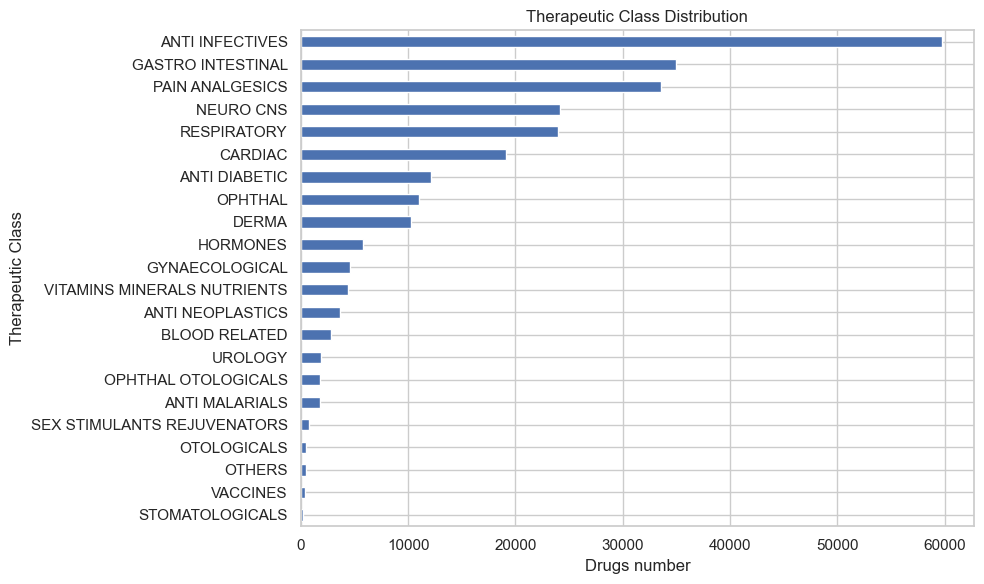

,count
Therapeutic Class,
ANTI INFECTIVES,59760
GASTRO INTESTINAL,34994
PAIN ANALGESICS,33551
NEURO CNS,24174
RESPIRATORY,24004
CARDIAC,19143
ANTI DIABETIC,12160
OPHTHAL,11021
DERMA,10307


In [5]:
tc_counts = df["Therapeutic Class"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
tc_counts.plot.barh(ax=ax)
ax.set_xlabel("Drugs number")
ax.set_title("Therapeutic Class Distribution")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(tc_counts.to_frame("count"))

In [7]:
has_comp1 = df["short_composition1"].notna().sum()
has_comp2 = df["short_composition2"].notna().sum()

print(f"Drugs with composition 1: {has_comp1} ({has_comp1 / len(df) * 100:.1f}%)")
print(f"Drugs with composition 2: {has_comp2} ({has_comp2 / len(df) * 100:.1f}%)")

Drugs with composition 1: 258127 (100.0%)
Drugs with composition 2: 112985 (43.8%)


## Side_effects Overview

count    258127.000000
mean          6.483200
std           4.192333
min           1.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          42.000000
Name: n_side_effects, dtype: float64


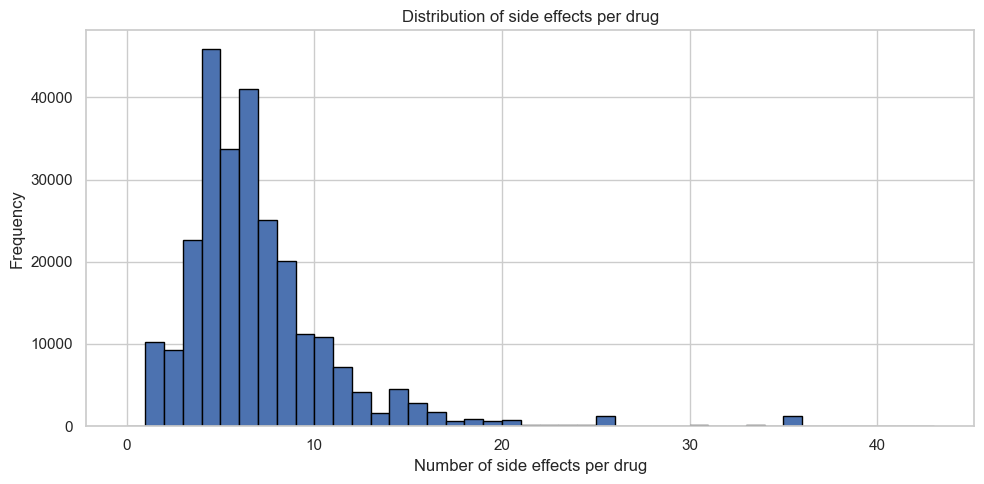

In [21]:
se_cols = [c for c in df.columns if c.startswith("sideEffect")]

df["n_side_effects"] = df[se_cols].notna().sum(axis=1)

print(df["n_side_effects"].describe())

fig, ax = plt.subplots(figsize=(10, 5))
df["n_side_effects"].hist(bins=range(0, df["n_side_effects"].max() + 2), ax=ax, edgecolor="black")
ax.set_xlabel("Number of side effects per drug")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of side effects per drug")
plt.tight_layout()
plt.show()

### Side Effect frequency

In [14]:
from collections import Counter

se_counter = Counter()
for col in se_cols:
    vals = df_comp[col].dropna().astype(str).str.strip()
    vals = vals[vals != ""]
    se_counter.update(vals)

se_freq = pd.DataFrame(se_counter.most_common(), columns=["side_effect", "n_drugs"])

display(se_freq.style.bar(subset=["n_drugs"], color="#5fba7d"))

,side_effect,n_drugs
0,Nausea,157428
1,Diarrhea,140295
2,Vomiting,100331
3,Headache,99015
4,Dizziness,72637
5,Stomach pain,50603
6,Rash,35749
7,Dryness in mouth,33984
8,Sleepiness,33516
9,Flatulence,32045


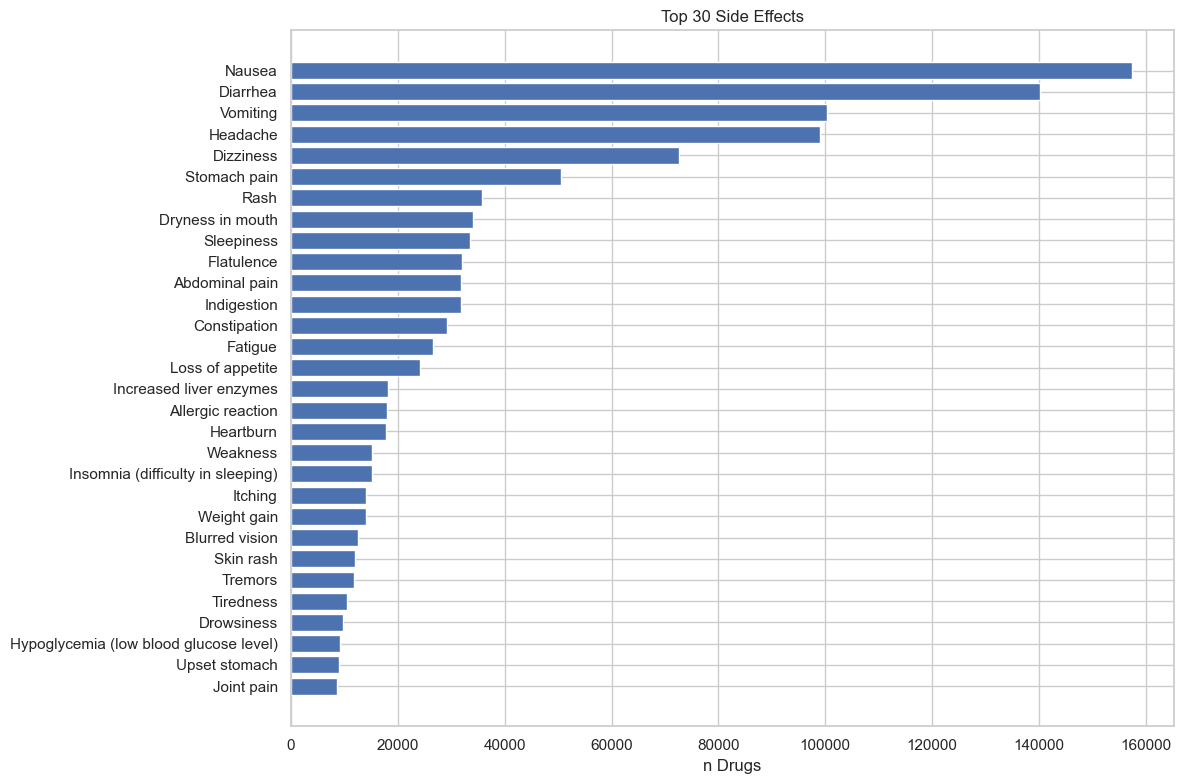

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
top = se_freq.head(30)
ax.barh(top["side_effect"], top["n_drugs"])
ax.set_xlabel("n Drugs")
ax.set_title("Top 30 Side Effects")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
thresholds = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

threshold_analysis = []
for t in thresholds:
    remaining = se_freq[se_freq["n_drugs"] >= t]
    threshold_analysis.append(
        {
            "threshold": t,
            "se_remaining": len(remaining),
            "se_removed": len(se_freq) - len(remaining),
            "pct_remaining": len(remaining) / len(se_freq) * 100,
        }
    )

df_thresh = pd.DataFrame(threshold_analysis)
display(df_thresh)

,threshold,se_remaining,se_removed,pct_remaining
0,0,1053,0,100.000000
1,1,1053,0,100.000000
2,2,969,84,92.022792
3,5,857,196,81.386515
4,10,777,276,73.789174
5,20,700,353,66.476733
6,50,550,503,52.231719
7,100,453,600,43.019943
8,200,351,702,33.333333
9,500,254,799,24.121557


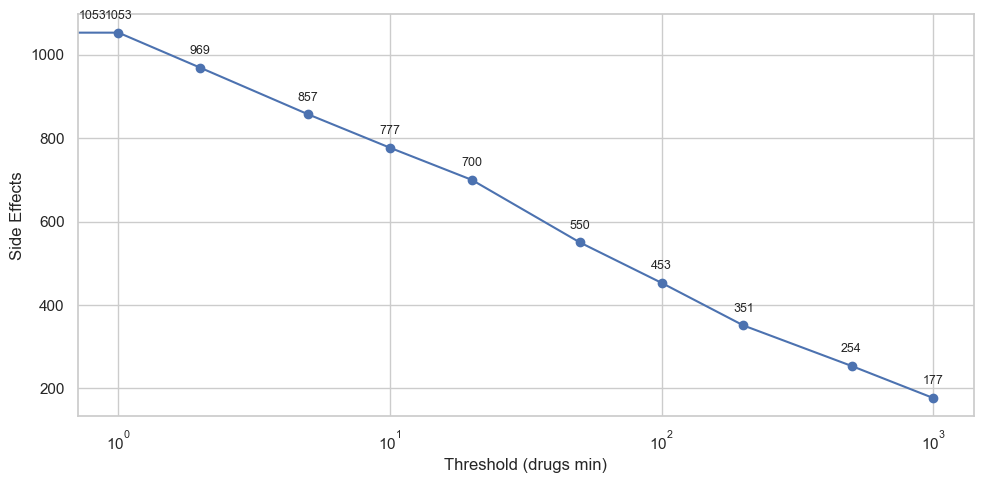

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh["threshold"], df_thresh["se_remaining"], marker="o")
ax.set_xlabel("Threshold (drugs min)")
ax.set_ylabel("Side Effects")
ax.set_xscale("log")

for _, row in df_thresh.iterrows():
    ax.annotate(
        f"{int(row['se_remaining'])}",
        (row["threshold"] if row["threshold"] > 0 else 0.8, row["se_remaining"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

,mean_se,median_se,n_drugs
Therapeutic Class,,,
ANTI NEOPLASTICS,10.231801,9.0,3654
NEURO CNS,9.035162,8.0,24174
RESPIRATORY,8.400683,8.0,24004
BLOOD RELATED,7.973970,6.0,2766
SEX STIMULANTS REJUVENATORS,7.739418,9.0,756
CARDIAC,7.720472,7.0,19143
HORMONES,7.160528,8.0,5837
GASTRO INTESTINAL,6.753958,6.0,34994
ANTI MALARIALS,6.479499,5.0,1756


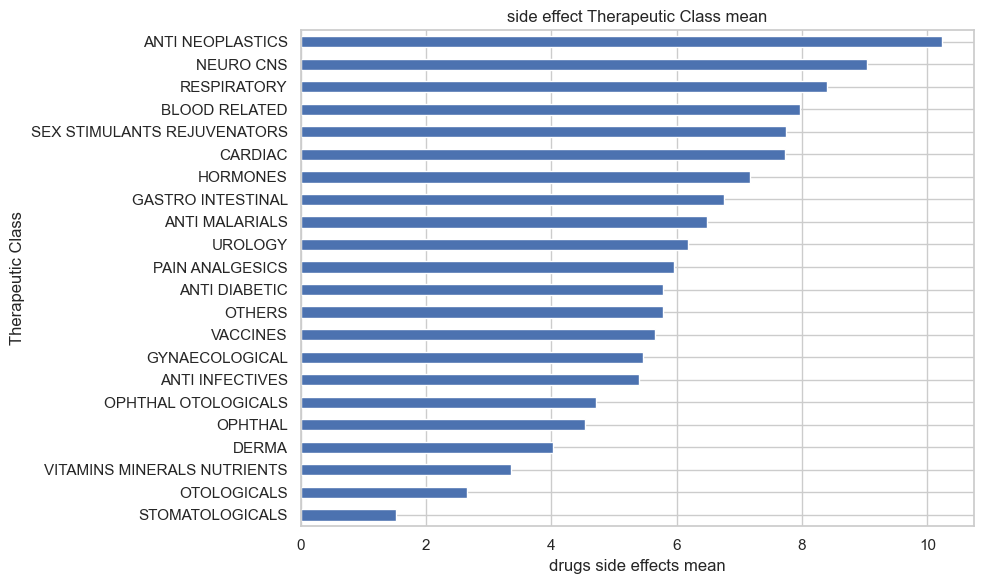

In [18]:
df["n_side_effects"] = df[se_cols].notna().sum(axis=1)

tc_se = (
    df.groupby("Therapeutic Class")["n_side_effects"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
tc_se.columns = ["mean_se", "median_se", "n_drugs"]

display(tc_se)

fig, ax = plt.subplots(figsize=(10, 6))
tc_se["mean_se"].plot.barh(ax=ax)
ax.set_xlabel("drugs side effects mean")
ax.set_title("side effect Therapeutic Class mean")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
for tc in df["Therapeutic Class"].dropna().unique():
    subset = df[df["Therapeutic Class"] == tc]
    tc_counter = Counter()
    for col in se_cols:
        vals = subset[col].dropna().astype(str).str.strip()
        vals = vals[vals != ""]
        tc_counter.update(vals)
    top5 = tc_counter.most_common(5)
    print(f"\n{tc} ({len(subset)} drugs):")
    for se, count in top5:
        print(f"  {se}: {count} ({count / len(subset) * 100:.1f}%)")


ANTI INFECTIVES (59760 drugs):
  Diarrhea: 53054 (88.8%)
  Nausea: 48416 (81.0%)
  Vomiting: 29613 (49.6%)
  Rash: 24353 (40.8%)
  Stomach pain: 14239 (23.8%)

RESPIRATORY (24004 drugs):
  Headache: 19317 (80.5%)
  Nausea: 16969 (70.7%)
  Vomiting: 16492 (68.7%)
  Sleepiness: 10856 (45.2%)
  Dizziness: 10795 (45.0%)

NEURO CNS (24174 drugs):
  Dizziness: 13114 (54.2%)
  Sleepiness: 12481 (51.6%)
  Nausea: 10810 (44.7%)
  Weight gain: 8336 (34.5%)
  Dryness in mouth: 8076 (33.4%)

GASTRO INTESTINAL (34994 drugs):
  Diarrhea: 27687 (79.1%)
  Headache: 26641 (76.1%)
  Dizziness: 19752 (56.4%)
  Nausea: 18342 (52.4%)
  Flatulence: 17116 (48.9%)

DERMA (10307 drugs):
  Application site reactions (burning, irritation, itching and redness): 5156 (50.0%)
  Skin peeling: 3221 (31.3%)
  Dry skin: 3061 (29.7%)
  Itching: 2810 (27.3%)
  Erythema (skin redness): 1491 (14.5%)

CARDIAC (19143 drugs):
  Headache: 12208 (63.8%)
  Nausea: 11920 (62.3%)
  Dizziness: 11548 (60.3%)
  Diarrhea: 7400 (38.7%